In [1]:
import pandas as pd

# load dataset
data = pd.read_csv("../data/CrimesOnWomenData.csv")

# preview dataset
data.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  736 non-null    int64 
 1   State       736 non-null    object
 2   Year        736 non-null    int64 
 3   Rape        736 non-null    int64 
 4   K&A         736 non-null    int64 
 5   DD          736 non-null    int64 
 6   AoW         736 non-null    int64 
 7   AoM         736 non-null    int64 
 8   DV          736 non-null    int64 
 9   WT          736 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 57.6+ KB


In [3]:
data.columns

Index(['Unnamed: 0', 'State', 'Year', 'Rape', 'K&A', 'DD', 'AoW', 'AoM', 'DV',
       'WT'],
      dtype='object')

In [4]:
data["Total_Crime"] = data.iloc[:,2:].sum(axis=1)

data.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crime
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,15670
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,2181
2,2,ASSAM,2001,817,1070,59,850,4,1248,0,6049
3,3,BIHAR,2001,888,518,859,562,21,1558,83,6490
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0,5965


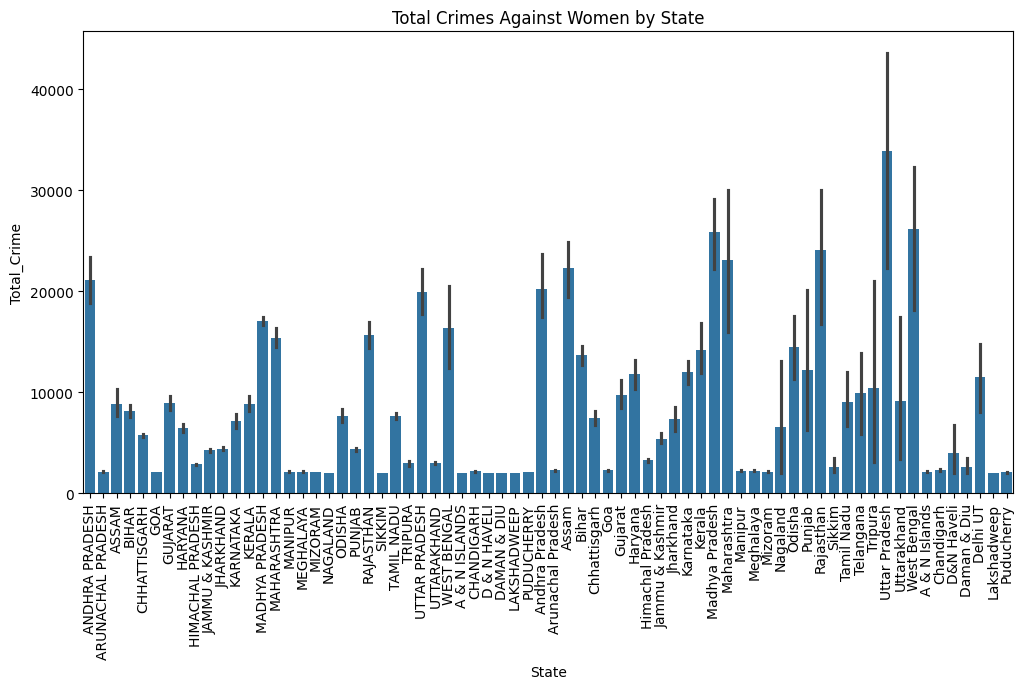

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(x="State", y="Total_Crime", data=data)

plt.xticks(rotation=90)
plt.title("Total Crimes Against Women by State")

plt.show()

In [6]:
data = data.drop(columns=["Unnamed: 0"])
data.head()

,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crime
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,15670
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,2181
2,ASSAM,2001,817,1070,59,850,4,1248,0,6049
3,BIHAR,2001,888,518,859,562,21,1558,83,6490
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0,5965


In [7]:
# normalize total crime values
data["Risk_Score"] = data["Total_Crime"] / data["Total_Crime"].max()

data.head()

,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT,Total_Crime,Risk_Score
0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7,15670,0.288784
1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0,2181,0.040194
2,ASSAM,2001,817,1070,59,850,4,1248,0,6049,0.111478
3,BIHAR,2001,888,518,859,562,21,1558,83,6490,0.119605
4,CHHATTISGARH,2001,959,171,70,1763,161,840,0,5965,0.109930


In [8]:
features = data[["Rape","K&A","DD","AoW","AoM","DV","WT"]]
target = data["Risk_Score"]

features.head()

,Rape,K&A,DD,AoW,AoM,DV,WT
0,871,765,420,3544,2271,5791,7
1,33,55,0,78,3,11,0
2,817,1070,59,850,4,1248,0
3,888,518,859,562,21,1558,83
4,959,171,70,1763,161,840,0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [10]:
predictions = model.predict(X_test)

predictions[:5]

array([0.08940142, 0.27330286, 0.04242914, 0.06500442, 0.31316372])

In [11]:
import pickle

pickle.dump(model, open("../model/safety_model.pkl","wb"))

print("Model saved")

Model saved
